# Data Processing Exploratory Data Analysis

## Setup

In [28]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
import os
import pathlib as Path
from __future__ import annotations
from typing import Dict, Any

In [2]:
import stanza
nlp = stanza.Pipeline('en')
print("Stanza ready!")

2025-10-24 15:04:47 INFO: Checking for updates to resources.json in case models have been updated.  Note: this behavior can be turned off with download_method=None or download_method=DownloadMethod.REUSE_RESOURCES


2025-10-24 15:04:47 INFO: Downloaded file to /Users/annaglass/stanza_resources/resources.json
2025-10-24 15:04:49 INFO: Loading these models for language: en (English):
| Processor    | Package                   |
--------------------------------------------
| tokenize     | combined                  |
| mwt          | combined                  |
| pos          | combined_charlm           |
| lemma        | combined_nocharlm         |
| constituency | ptb3-revised_charlm       |
| depparse     | combined_charlm           |
| sentiment    | sstplus_charlm            |
| ner          | ontonotes-ww-multi_charlm |

2025-10-24 15:04:49 INFO: Using device: cpu
2025-10-24 15:04:49 INFO: Loading: tokenize
2025-10-24 15:04:50 INFO: Loading: mwt
2025-10-24 15:04:50 INFO: Loading: pos
2025-10-24 15:04:51 INFO: Loading: lemma
2025-10-24 15:04:51 INFO: Loading: constituency
2025-10-24 15:04:52 INFO: Loading: depparse
2025-10-24 15:04:52 INFO: Loading: sentiment
2025-10-24 15:04:52 INFO: Loading: n

Stanza ready!


## Raw Data Exploration

In [3]:
import os
print(os.getcwd())

/Users/annaglass/capstone/capstone/analysis


In [4]:
# Choosing one file for example for processing decisions
rawDF = pd.read_excel("../data_storage/raw_data/penta_raw_1.xlsx", engine="openpyxl")

/opt/anaconda3/lib/python3.12/site-packages/openpyxl/styles/stylesheet.py:226: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


In [5]:
rawDF.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 499999 entries, 0 to 499998
Data columns (total 31 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   tag_name            499999 non-null  object        
 1   article_id          499999 non-null  int64         
 2   source_feed_name    499999 non-null  object        
 3   load_date           499999 non-null  datetime64[ns]
 4   load_datetime       499999 non-null  datetime64[ns]
 5   feed_name           499999 non-null  object        
 6   headline            499992 non-null  object        
 7   article_body        499999 non-null  object        
 8   author_name         499109 non-null  object        
 9   source_unique_id    499942 non-null  object        
 10  source_type_name    499999 non-null  object        
 11  channel_name        499999 non-null  object        
 12  genre               58044 non-null   object        
 13  publisher_name      496870 no

In [6]:
rawDF.head()

,tag_name,article_id,source_feed_name,load_date,load_datetime,feed_name,headline,article_body,author_name,source_unique_id,...,iso_language_code,circulation_size,page,sentiment_score,source_type,engagement,sentiment_band,hit_strength,vipr_weight,vipr_score
0,Public Health,17813004513,regionals-web,2024-01-01,2024-01-01 00:00:07.895,opoint,Inside the family-run dairy farm at centre of ...,"Mrs Kirkham's Lancashire Cheese, which is loc...","Rory Tingle, Emily Stearn",4394-12152242,...,en,156069,NaN,-18,Regional News,0,Negative,1,350,-6300
1,Health Campaign,17813005960,consumer,2024-01-01,2024-01-01 00:00:17.311,opoint,Saiba como agir em casos de queimadura por fog...,A virada de Ano Novo é comumente marcada pe...,uncredited,259876-24234,...,pt,47524,NaN,-31,Consumer,0,Negative,1,105,-3255
2,Health Campaign,17813007006,regionals-web,2024-01-01,2024-01-01 00:00:12.570,opoint,列宁的6个墨水瓶：贫穷限制了你的想象力，也限制了你的购买力,1980年代我读小学，有篇课文讲的是列宁。列宁想在狱中写书，但监狱里只能看书不允许写字，既...,uncredited,43329-9359961,...,zh,43879575,NaN,-16,Regional News,0,Negative,1,400,-6400
3,Public Health,17813007724,broadcast-radio,2024-01-01,2024-01-01 00:00:43.095,tveyes,4BC 1116 News Talk: A bit of rat boys and they...,"A bit of rat boys and they mix it up, stick a...",uncredited,f845c9c8-0908-4d2c-98d2-e84596f8f390,...,en,1019,NaN,-18,Radio,0,Negative,1,312,-5616
4,Public Health,17813008458,broadcast-radio,2024-01-01,2024-01-01 00:00:06.199,tveyes,ABC South East SA: I'd be doing. But if you wo...,I'd be doing. But if you would have asked me ...,uncredited,c236e220-ce6f-450d-b97f-b862631e7512,...,en,1154,NaN,22,Radio,0,Positive,2,262,5764


In [7]:
# Check for Missing Values
rawDF.isna().sum()

tag_name                   0
article_id                 0
source_feed_name           0
load_date                  0
load_datetime              0
feed_name                  0
headline                   7
article_body               0
author_name              890
source_unique_id          57
source_type_name           0
channel_name               0
genre                 441955
publisher_name          3129
publication_name           0
publisher_site_url      2099
published_datetime         0
article_url                0
region                 46709
subregion             172508
country                    0
iso_language_code         10
circulation_size           0
page                  498470
sentiment_score            0
source_type                0
engagement                 0
sentiment_band             0
hit_strength               0
vipr_weight                0
vipr_score                 0
dtype: int64

In [8]:
# Dropped Column Analysis
DROP_COLS = ["publisher_site_url"
             ,"page"              # Not needed
             ,"article_url"       # Not needed 
             ,"source_unique_id"  # Not needed
             ,"source_type_name"  # Duplicate column with source_type
             ,"region"            # Very messy data after filtering to US, does not provide value. 
             ,"load_datetime"     # Not needed 
             ,"engagement"        # Not a used column by Penta  
             ,"genre"             # Not a used column by Penta  
             ,"iso_language_code" # Not needed as all items are in English after filtering 
             ,"load_date"         # Want to use the published_date" 
             ]
rawDF[DROP_COLS].head()

,publisher_site_url,page,article_url,source_unique_id,source_type_name,region,load_datetime,engagement,genre,iso_language_code,load_date
0,https://www.einnews.com,NaN,https://foodsafety.einnews.com/article/678033599,4394-12152242,Regional News,North America,2024-01-01 00:00:07.895,0,NaN,en,2024-01-01
1,https://www.gruporioclarosp.com.br,NaN,https://www.gruporioclarosp.com.br/2023/12/31/...,259876-24234,Consumer,Latin America,2024-01-01 00:00:17.311,0,NaN,pt,2024-01-01
2,http://www.163.com,NaN,https://m.163.com/news/article/INAC5CEN05563SW...,43329-9359961,Regional News,Asia,2024-01-01 00:00:12.570,0,NaN,zh,2024-01-01
3,Broadcast,NaN,https://penta.live/getBroadcastArticleLink?art...,f845c9c8-0908-4d2c-98d2-e84596f8f390,Radio,NaN,2024-01-01 00:00:43.095,0,AURAD4BC,en,2024-01-01
4,Broadcast,NaN,https://penta.live/getBroadcastArticleLink?art...,c236e220-ce6f-450d-b97f-b862631e7512,Radio,NaN,2024-01-01 00:00:06.199,0,AURADABCSOUTHEASTSA,en,2024-01-01


In [9]:
NUMERIC_REQUIRED = ["vipr_weight", "circulation", "sentiment"] 

def apply_filters(df: pd.DataFrame) -> pd.DataFrame:
    print(f"start:            {df.shape[0]:,} rows × {df.shape[1]} cols")

    # 1) drop NA in required numeric columns (only those that exist)
    req = [c for c in NUMERIC_REQUIRED if c in df.columns]
    if req:
        df = df.dropna(subset=req)
    print(f"after dropna:     {df.shape[0]:,} rows × {df.shape[1]} cols (req={req})")

    # 2) filter to US
    if "country" in df.columns:
        df = df[df["country"] == "United States"]
    print(f"after US filter:  {df.shape[0]:,} rows × {df.shape[1]} cols")

    # 3) drop metadata columns (only those that exist)
    drops = [c for c in DROP_COLS if c in df.columns]
    df = df.drop(columns=drops, errors="ignore")
    print(f"after drop cols:  {df.shape[0]:,} rows × {df.shape[1]} cols (dropped {len(drops)})")

    return df.head(5)

apply_filters(rawDF)

start:            499,999 rows × 31 cols
after dropna:     499,999 rows × 31 cols (req=['vipr_weight'])
after US filter:  117,388 rows × 31 cols
after drop cols:  117,388 rows × 20 cols (dropped 11)


,tag_name,article_id,source_feed_name,feed_name,headline,article_body,author_name,channel_name,publisher_name,publication_name,published_datetime,subregion,country,circulation_size,sentiment_score,source_type,sentiment_band,hit_strength,vipr_weight,vipr_score
0,Public Health,17813004513,regionals-web,opoint,Inside the family-run dairy farm at centre of ...,"Mrs Kirkham's Lancashire Cheese, which is loc...","Rory Tingle, Emily Stearn",Web,Ein News,Ein News,2023-12-29 17:18:24.000,NaN,United States,156069,-18,Regional News,Negative,1,350,-6300
15,Public Health,17813026449,wires,opoint,German cardinal says Pope Francis’ same-sex bl...,A German cardinal in the Catholic Church rema...,uncredited,Web,Lucianne,Lucianne,2024-01-01 00:06:15.000,NaN,United States,59374,-27,Wires,Negative,1,25,-675
23,Public Health,17813035135,consumer,opoint,'23 SAW SIGNIFICANT POSITIVE DEVELOPMENTS IN S...,"TUESDAY, DECEMBER 26, 2023 2023 was a toug...",Al Cross,Web,The Levisa Lazer,The Levisa Lazer,2024-01-01 00:08:07.000,NaN,United States,845,-21,Consumer,Negative,2,500,-10500
30,Public Health,17813043680,broadcast-tv,tveyes,NHL Hockey,Boston Bruins at Detroit Red Wings. From Littl...,uncredited,Broadcast,Bally Sports Detroit,Bally Sports Detroit,2023-12-31 23:59:33.615,NaN,United States,818,8,TV,Neutral,1,271,2168
37,Public Health,17813051573,regionals-web,opoint,Death rates from rare heart diseases rise amon...,Researchers warn that the opioid epidemic i...,Remon Buul,Web,News Net Daily,News Net Daily,2023-12-31 18:00:46.000,NaN,United States,9403,-43,Regional News,Negative,4,1122,-48246


The majority of data processing decisions are made with computer resources at top of mind, specifically concerning the filtering, besides dropping missing values. Knowing GitHubs size limit of files of 10MB to be pushed, and Streamlit's ability to only work with 1 GB of data, filtering decisions for country, region, and language had to be made. In an ideal world, these columns could be used to further cluster and analyze the data. The only other data processing done was appending this with the other 9 raw data files, as well as processing the text data to start with a clean base. One item that was noticied was inconsistencies in the naming convention for "Unknown" or "Other" items in categorical columns. This was addressed in data processing. 

## Processed Data

In [10]:
import os
os.getcwd()

'/Users/annaglass/capstone/capstone/analysis'

In [11]:
cleanDF = pd.read_parquet("../data_storage/processed_data/processed_data.parquet")

In [12]:
cleanDF.head()

,article_body,article_id,author_name,channel_name,circulation_size,feed_name,headline,hit_strength,publication_name,published_datetime,...,sentiment_band,sentiment_score,source_feed_name,source_type,tag_name,vipr_score,vipr_weight,headline_token_count,body_token_count,token_count
0,mr kirkham lancashire cheese located picturesq...,17813004513,rory_tingle_emily_stearn,web,156069,opoint,inside family run dairy farm centre coli outbr...,1,ein_news,2023-12-29 17:18:24+00:00,...,negative,-18,regionals_web,regional_news,public_health,-6300,350,20,662,682
1,german cardinal catholic church remarked pope ...,17813026449,unknown,web,59374,opoint,german cardinal say pope francis sex blessing ...,1,lucianne,2024-01-01 00:06:15+00:00,...,negative,-27,wires,wires,public_health,-675,25,10,700,710
2,tuesday december tough year many way saw signi...,17813035135,al_cross,web,845,opoint,saw significant positive development science m...,2,the_levisa_lazer,2024-01-01 00:08:07+00:00,...,negative,-21,consumer,consumer,public_health,-10500,500,6,286,292
3,boston bruin detroit red wing little caesar ar...,17813043680,unknown,broadcast,818,tveyes,nhl hockey,1,bally_sports_detroit,2023-12-31 23:59:33.615000+00:00,...,neutral,8,broadcast_tv,tv,public_health,2168,271,2,379,381
4,researcher warn opioid epidemic fueling deadly...,17813051573,remon_buul,web,9403,opoint,death rate rare heart disease rise among young...,4,news_net_daily,2023-12-31 18:00:46+00:00,...,negative,-43,regionals_web,regional_news,public_health,-48246,1122,9,677,686


In [13]:
cleanDF.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 899519 entries, 0 to 899518
Data columns (total 21 columns):
 #   Column                Non-Null Count   Dtype                         
---  ------                --------------   -----                         
 0   article_body          899519 non-null  string                        
 1   article_id            899519 non-null  Int64                         
 2   author_name           899519 non-null  string                        
 3   channel_name          899519 non-null  string                        
 4   circulation_size      899519 non-null  Int64                         
 5   feed_name             899519 non-null  string                        
 6   headline              899519 non-null  string                        
 7   hit_strength          899519 non-null  Int64                         
 8   publication_name      899519 non-null  string                        
 9   published_datetime    899518 non-null  timestamp[ns, tz=UTC

In [14]:
cleanDF.isna().sum()

article_body            0
article_id              0
author_name             0
channel_name            0
circulation_size        0
feed_name               0
headline                0
hit_strength            0
publication_name        0
published_datetime      1
publisher_name          0
sentiment_band          0
sentiment_score         0
source_feed_name        0
source_type             0
tag_name                0
vipr_score              0
vipr_weight             0
headline_token_count    0
body_token_count        0
token_count             0
dtype: int64

In [15]:
from pathlib import Path

path = Path("data_storage/processed_data/processed_data.parquet")

print(f"Observations: {cleanDF.shape[0]:,} rows × {cleanDF.shape[1]} columns")
print(f"In-memory size: {cleanDF.memory_usage(deep=True).sum() / (1024 ** 2):.2f} MB")

Observations: 899,519 rows × 21 columns
In-memory size: 3438.50 MB


The dataset has gone through text processing, filtering, and is in great shape for modeling now. However, looking at the size of the dataset, it is far too large to be used for modeling under the computational constraints of the capstone project. This leads us to sampling the data. 

## Sampled Dataset

The sampling technique used was originally SFFS to protect the network of individuals, however after talking with Penta, priorities moved away from the network analysis. We decided to use stratified sampling because it has a similar logic concept to SFFS, however, it is much more computationally effective, as SFFS took 12+ hours to run. 

In [16]:
sampleDF = pd.read_parquet("../data_storage/processed_data/sampled_data.parquet")

In [17]:
sampleDF.head()

,article_body,article_id,author_name,channel_name,circulation_size,feed_name,headline,hit_strength,publication_name,published_datetime,...,sentiment_band,sentiment_score,source_feed_name,source_type,tag_name,vipr_score,vipr_weight,headline_token_count,body_token_count,token_count
0,johannesburg south africa los angeles calif ja...,17875604184,unknown,web,800,opoint,scientology africa five year unconditional hel...,3,daily_journal,2024-01-20 11:54:19+00:00,...,positive,26,regionals_web,regional_news,public_health,23400,900,13,510,523
1,news provided ein presswire apr london united ...,18122540973,unknown,web,1066890,opoint,health political choice advancing indigenous p...,7,wkrn,2024-04-07 14:13:13+00:00,...,positive,34,regionals_web,regional_news,public_health,44608,1312,10,357,367
2,honor earth day chamber county community healt...,18172305397,charlotte_reames,web,14529,opoint,wellness center launch garden micro pantry ear...,2,valley_times_news,2024-04-23 14:16:06+00:00,...,positive,20,regionals_web,regional_news,public_health,20220,1011,8,202,210
3,lima wlio flu season reach peak hospital publi...,19107290711,todd_cummins,web,37122,opoint,flu case surge allen county health official ur...,6,hometown_lima_stations,2025-02-13 00:15:22+00:00,...,neutral,-3,regionals_web,regional_news,public_health,-4998,1666,13,156,169
4,cnn number measles case around world nearly do...,18186873367,katherine_dillinger,web,1038,opoint,global measles case nearly doubled one year re...,2,cnn_edition,2024-04-27 22:09:46+00:00,...,neutral,0,web,general_news,public_health,0,1083,9,290,299


In [18]:
sampleDF.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 21 columns):
 #   Column                Non-Null Count   Dtype                         
---  ------                --------------   -----                         
 0   article_body          100000 non-null  string                        
 1   article_id            100000 non-null  Int64                         
 2   author_name           100000 non-null  string                        
 3   channel_name          100000 non-null  string                        
 4   circulation_size      100000 non-null  Int64                         
 5   feed_name             100000 non-null  string                        
 6   headline              100000 non-null  string                        
 7   hit_strength          100000 non-null  Int64                         
 8   publication_name      100000 non-null  string                        
 9   published_datetime    100000 non-null  timestamp[ns, tz=UTC]

In [19]:
sampleDF.isna().sum()

article_body            0
article_id              0
author_name             0
channel_name            0
circulation_size        0
feed_name               0
headline                0
hit_strength            0
publication_name        0
published_datetime      0
publisher_name          0
sentiment_band          0
sentiment_score         0
source_feed_name        0
source_type             0
tag_name                0
vipr_score              0
vipr_weight             0
headline_token_count    0
body_token_count        0
token_count             0
dtype: int64

In [20]:
# Check Size of Dataset
path = Path("data_storage/processed_data/sampled_data.parquet")

print(f"Observations: {cleanDF.shape[0]:,} rows × {cleanDF.shape[1]} columns")
print(f"In-memory size: {cleanDF.memory_usage(deep=True).sum() / (1024 ** 2):.2f} MB")

Observations: 899,519 rows × 21 columns
In-memory size: 3438.50 MB


Now that the data has been sampled down a great amount, there will be fewer issues in modeling and future efforts. One key takeaway here is that we will have to split the dataset into 4 parts to push to Github, and ultimately be pushed to Streamlit. 

## Trends & Analysis

As the sampled dataset is what we are going to be using for modeling, a detailed exploratory analysis is performed below.

In [21]:
print("\nBasic Statistics (Numeric Columns):")
print(sampleDF.describe())


Basic Statistics (Numeric Columns):
              article_id  circulation_size  hit_strength  \
count           100000.0          100000.0      100000.0   
mean   18786801662.47744     2264837.42243       3.36156   
min        17813026449.0               1.0           0.0   
25%       18341041670.25            1045.0           1.0   
50%        18825191460.0            6932.0           2.0   
75%        19234312837.0          156578.5           4.0   
max        19683932188.0       428640966.0         170.0   
std     526254801.285261   20547342.341867      3.637258   

                        published_datetime  sentiment_score    vipr_score  \
count                               100000         100000.0      100000.0   
mean   2024-11-01 06:52:16.064954624+00:00         -7.87898   -6716.08988   
min              2008-12-31 11:55:40+00:00           -100.0    -1080000.0   
25%    2024-06-14 21:07:25.750000128+00:00            -25.0      -13570.0   
50%    2024-11-15 11:04:55.271000064+

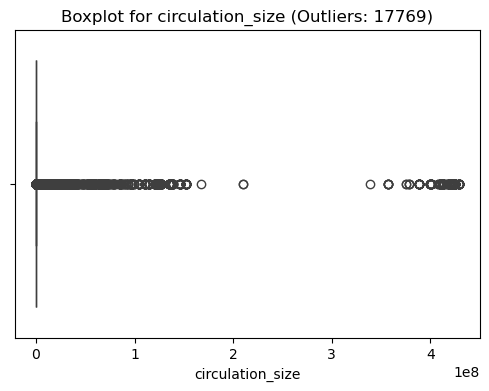

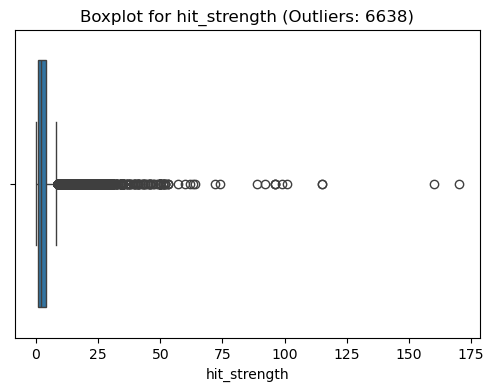

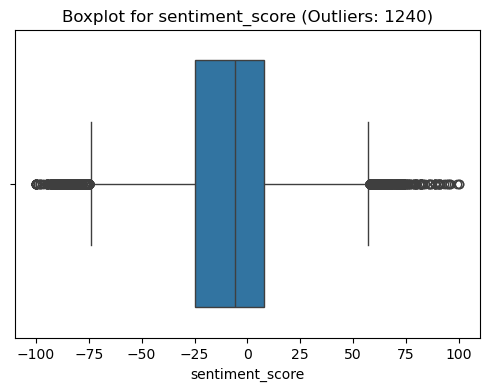

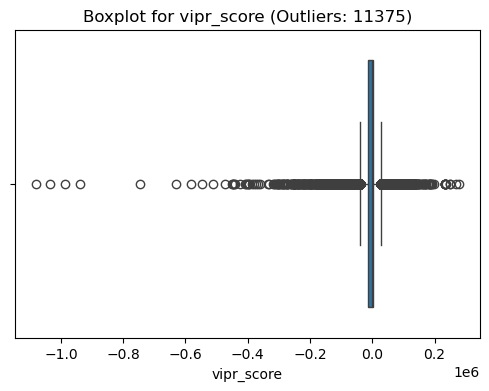

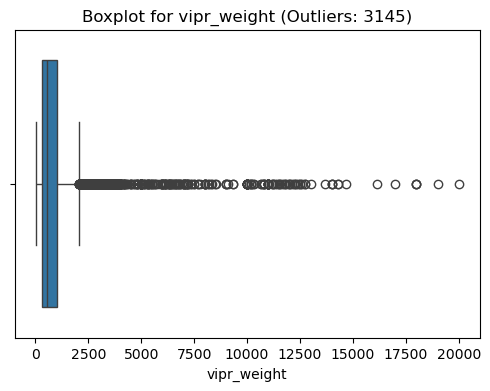

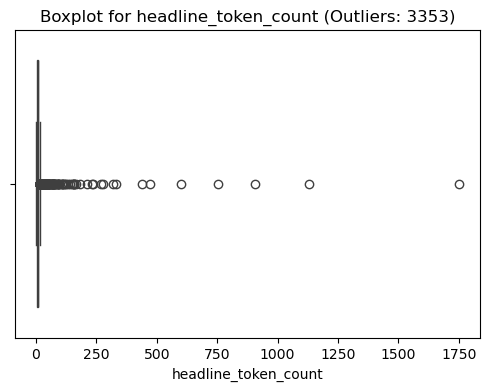

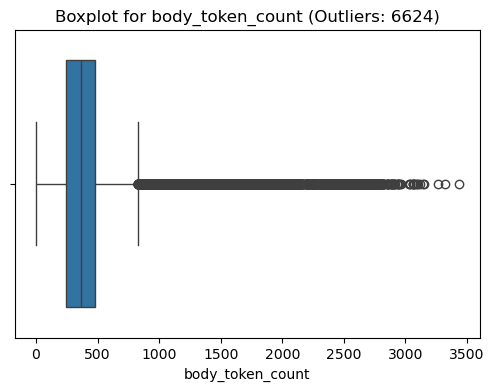

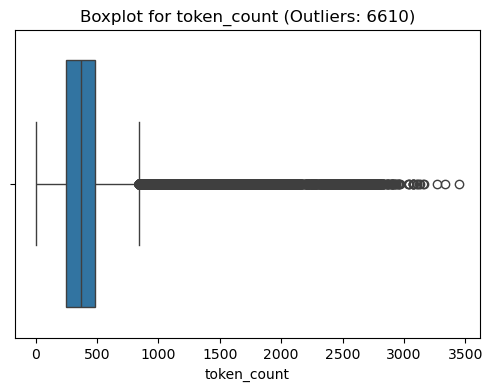

Outlier counts by column:
{'circulation_size': 17769, 'hit_strength': 6638, 'sentiment_score': 1240, 'vipr_score': 11375, 'vipr_weight': 3145, 'headline_token_count': 3353, 'body_token_count': 6624, 'token_count': 6610}


,article_body,article_id,author_name,channel_name,circulation_size,feed_name,headline,hit_strength,publication_name,published_datetime,...,sentiment_band,sentiment_score,source_feed_name,source_type,tag_name,vipr_score,vipr_weight,headline_token_count,body_token_count,token_count
0,johannesburg south africa los angeles calif ja...,17875604184,unknown,web,800,opoint,scientology africa five year unconditional hel...,3,daily_journal,2024-01-20 11:54:19+00:00,...,positive,26,regionals_web,regional_news,public_health,23400,900,13,510,523
1,news provided ein presswire apr london united ...,18122540973,unknown,web,1066890,opoint,health political choice advancing indigenous p...,7,wkrn,2024-04-07 14:13:13+00:00,...,positive,34,regionals_web,regional_news,public_health,44608,1312,10,357,367
2,honor earth day chamber county community healt...,18172305397,charlotte_reames,web,14529,opoint,wellness center launch garden micro pantry ear...,2,valley_times_news,2024-04-23 14:16:06+00:00,...,positive,20,regionals_web,regional_news,public_health,20220,1011,8,202,210
3,lima wlio flu season reach peak hospital publi...,19107290711,todd_cummins,web,37122,opoint,flu case surge allen county health official ur...,6,hometown_lima_stations,2025-02-13 00:15:22+00:00,...,neutral,-3,regionals_web,regional_news,public_health,-4998,1666,13,156,169
4,cnn number measles case around world nearly do...,18186873367,katherine_dillinger,web,1038,opoint,global measles case nearly doubled one year re...,2,cnn_edition,2024-04-27 22:09:46+00:00,...,neutral,0,web,general_news,public_health,0,1083,9,290,299
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,uganda launch malaria vaccination million chil...,19274728697,unknown,web,64723,opoint,uganda launch malaria vaccination million child,2,mangaloreancom,2025-04-03 03:01:50+00:00,...,positive,20,regionals_web,regional_news,public_health,15320,766,6,286,292
99996,rzburg germany cambridge mass jan globe newswi...,17887728142,unknown,web,855,opoint,fighting leprosy artificial intelligence dahw ...,2,connect_iredell,2024-01-24 10:12:56+00:00,...,neutral,-5,consumer,consumer,public_health,-875,175,20,719,739
99997,news press release humanitarian situation civi...,18273809943,unknown,web,1151885,opoint,sudan deteriorating situation fasher health sy...,1,reliefweb,2024-05-24 20:35:55+00:00,...,negative,-46,web,general_news,public_health,-11500,250,8,326,334
99998,originally published minute medicine view orig...,18593501644,thomas_su,web,194982,opoint,individualized acupuncture associated signific...,1,accessmedicine,2024-09-05 11:24:44+00:00,...,negative,-64,consumer,consumer,world_health_leadership,-17344,271,8,419,427


In [22]:
def detect_outliers_iqr(df, cols, remove=False):
    outlier_indices = {}
    df_clean = sampleDF.copy()
    
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        outlier_indices[col] = len(outliers)
        
    
        if remove:
            df_clean = df_clean[(df_clean[col] >= lower_bound) & (df_clean[col] <= upper_bound)]
        
        
        plt.figure(figsize=(6, 4))
        sns.boxplot(x=df[col])
        plt.title(f"Boxplot for {col} (Outliers: {len(outliers)})")
        plt.show()
    
    print("Outlier counts by column:")
    print(outlier_indices)
    
    return df_clean

numeric_cols = [c for c in sampleDF.select_dtypes(include="number").columns if c != "article_id"]
detect_outliers_iqr(sampleDF, numeric_cols, remove = False)

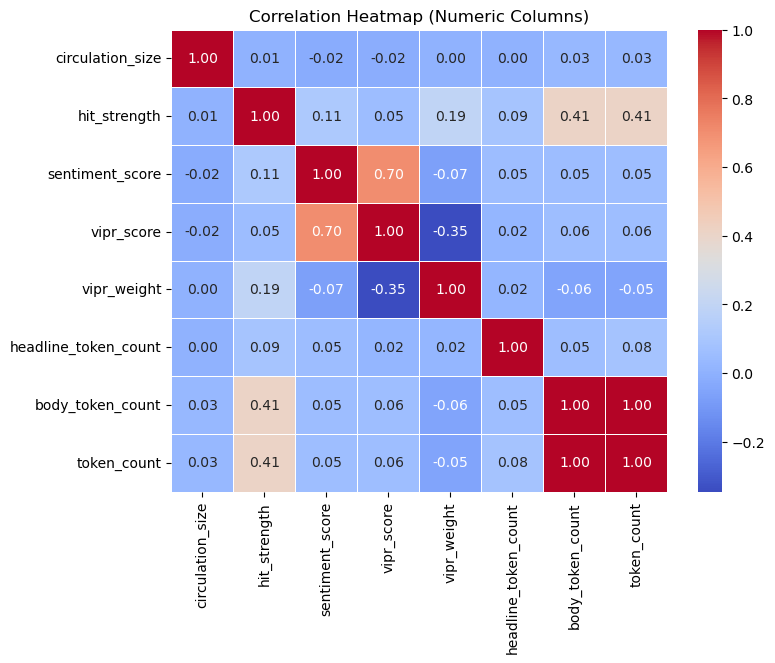

In [23]:
corr_matrix = sampleDF[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap (Numeric Columns)")
plt.show()

Results show signs of multicolinearity with token count columns, however, they are more used for general reference to see the length of the article -- therefore is not a worry. 

In [24]:
sampleDF.columns

Index(['article_body', 'article_id', 'author_name', 'channel_name',
       'circulation_size', 'feed_name', 'headline', 'hit_strength',
       'publication_name', 'published_datetime', 'publisher_name',
       'sentiment_band', 'sentiment_score', 'source_feed_name', 'source_type',
       'tag_name', 'vipr_score', 'vipr_weight', 'headline_token_count',
       'body_token_count', 'token_count'],
      dtype='object')

In [26]:
# Parse and keep UTC tz-aware
sampleDF['published_datetime'] = pd.to_datetime(
    sampleDF['published_datetime'], errors='coerce', utc=True
)

# (optional) convert to America/New_York but stay tz-aware
sampleDF['published_datetime'] = sampleDF['published_datetime'].dt.tz_convert('America/New_York')

In [35]:
def eda_tables_dual(df: pd.DataFrame) -> Dict[str, Dict[str, pd.DataFrame]]:
    """
    Build EDA tables for:
      - Top publications (article_count, avg_circulation)
      - Avg circulation by source type
      - EDA by channel (article_count, avg_circulation)
      - Daily article & circulation distribution
      - Monthly article & circulation distribution
      - Sentiment band EDA (distribution)
      - Sentiment score EDA (summary + by band)

    Returns:
      {
        "full": { <tables> },
        "conversion": { <tables> }  # only if 'conversion_proxy' in df
      }
    """

    # -------- Robust datetime normalization (works for Arrow-backed + tz-aware) --------
    if "published_datetime" not in df.columns:
        raise KeyError("Column 'published_datetime' is required for EDA tables.")

    # Parse to UTC-aware first (safe regardless of current dtype), then convert to NY for reporting
    _pub = pd.to_datetime(df["published_datetime"], errors="coerce", utc=True)
    _pub_local = _pub.dt.tz_convert("America/New_York")

    # Day key (naive date objects for grouping/plot x-axes)
    _day_key = _pub_local.dt.tz_localize(None).dt.date

    # Month key (first day of month as naive timestamp) — avoids .dt.to_period() entirely
    _month_key = pd.to_datetime(_pub_local.dt.strftime("%Y-%m-01")).dt.tz_localize(None)

    # Convenience: ensure some columns exist to prevent KeyErrors; if missing, create neutral defaults
    df = df.copy()
    if "article_id" not in df.columns:
        df["article_id"] = 1
    if "circulation_size" not in df.columns:
        df["circulation_size"] = pd.NA
    if "publication_name" not in df.columns:
        df["publication_name"] = pd.NA
    if "channel_name" not in df.columns:
        df["channel_name"] = pd.NA
    if "sentiment_band" not in df.columns:
        df["sentiment_band"] = pd.NA

    # prefer source_type_name when available
    st_col = "source_type_name" if "source_type_name" in df.columns else ("source_type" if "source_type" in df.columns else None)
    if st_col is None:
        df["source_type"] = pd.NA
        st_col = "source_type"

    def _build(sub_df: pd.DataFrame) -> Dict[str, pd.DataFrame]:
        out: Dict[str, Any] = {}

        # attach time keys without modifying caller’s frame
        sub_df = sub_df.assign(DAY=_day_key.loc[sub_df.index], MONTH=_month_key.loc[sub_df.index])

        # ---- 1) Top publications
        out["top_publications"] = (
            sub_df.groupby("publication_name", dropna=False)
                  .agg(article_count=("article_id", "count"),
                       avg_circulation=("circulation_size", "mean"))
                  .sort_values(["article_count", "avg_circulation"], ascending=[False, False])
                  .head(25)
                  .reset_index()
        )

        # ---- 2) Avg circulation by source type
        out["avg_circulation_by_source_type"] = (
            sub_df.groupby(st_col, dropna=False)
                  .agg(avg_circulation=("circulation_size", "mean"),
                       median_circulation=("circulation_size", "median"),
                       article_count=("article_id", "count"))
                  .sort_values("avg_circulation", ascending=False)
                  .reset_index()
        )

        # ---- 3) EDA by channel (count + avg circ)
        out["by_channel"] = (
            sub_df.groupby("channel_name", dropna=False)
                  .agg(article_count=("article_id", "count"),
                       avg_circulation=("circulation_size", "mean"))
                  .sort_values(["article_count", "avg_circulation"], ascending=[False, False])
                  .reset_index()
        )

        # ---- 4) Daily distribution (articles + total circulation)
        out["daily_distribution"] = (
            sub_df.groupby("DAY", as_index=False)
                  .agg(article_count=("article_id", "count"),
                       circulation_total=("circulation_size", "sum"))
                  .sort_values("DAY")
        )

        # ---- 5) Monthly distribution (articles + total circulation)
        out["monthly_distribution"] = (
            sub_df.groupby("MONTH", as_index=False)
                  .agg(article_count=("article_id", "count"),
                       circulation_total=("circulation_size", "sum"))
                  .sort_values("MONTH")
        )

        # ---- 6) Sentiment band EDA
        sb = sub_df["sentiment_band"].value_counts(dropna=False).rename_axis("sentiment_band").reset_index(name="count")
        total_rows = int(len(sub_df))
        if total_rows > 0:
            sb["pct"] = (sb["count"] / total_rows * 100).round(2)
        out["sentiment_band_distribution"] = sb

        # ---- 7) Sentiment score EDA
        if "sentiment_score" in sub_df.columns:
            out["sentiment_score_summary"] = sub_df["sentiment_score"].describe().to_frame("value")
            out["sentiment_score_by_band"] = (
                sub_df.groupby("sentiment_band", dropna=False)["sentiment_score"]
                      .agg(mean="mean", median="median", std="std", count="count")
                      .reset_index()
                      .sort_values("mean", ascending=False)
            )
        else:
            out["sentiment_score_summary"] = pd.DataFrame()
            out["sentiment_score_by_band"] = pd.DataFrame()

        return out

    results: Dict[str, Dict[str, pd.DataFrame]] = {"full": _build(df)}

    # add conversion subset if available
    if "conversion_proxy" in df.columns:
        results["conversion"] = _build(df[df["conversion_proxy"] == 1].copy())

    return results

eda_tables_dual(sampleDF)["full"]

{'top_publications':                                   publication_name  article_count  \
 0   multidisciplinary_digital_publishing_institute            827   
 1                                      head_topics            568   
 2                                          archyde            473   
 3                                       archynetys            381   
 4                                           medium            357   
 5                                       news_break            296   
 6                                        reliefweb            272   
 7                                              aol            270   
 8                                   medical_xpress            270   
 9                                       world_news            270   
 10                                            ncbi            263   
 11                                     newsy_today            255   
 12                                             msn            250   


In [34]:
tables_dual = eda_tables_dual(sampleDF)
tables_dual["full"]["by_channel"].head()

,channel_name,article_count,avg_circulation
0,web,76153,2845982.209447
1,broadcast,19361,309208.68607
2,social,4329,867222.309078
3,print,157,81938.216561


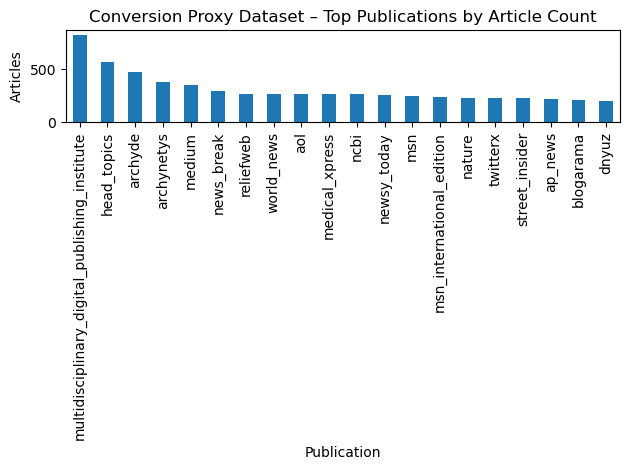

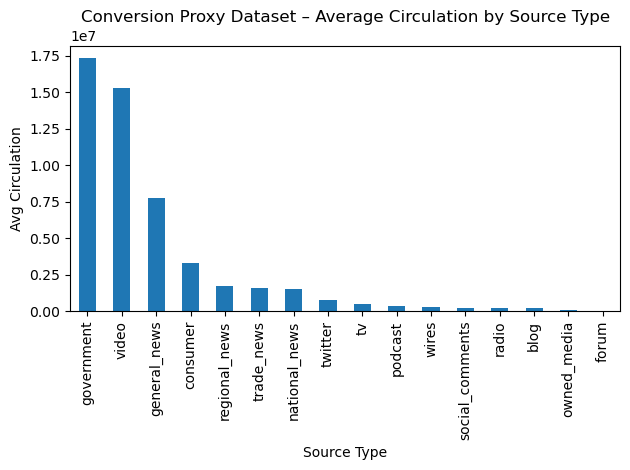

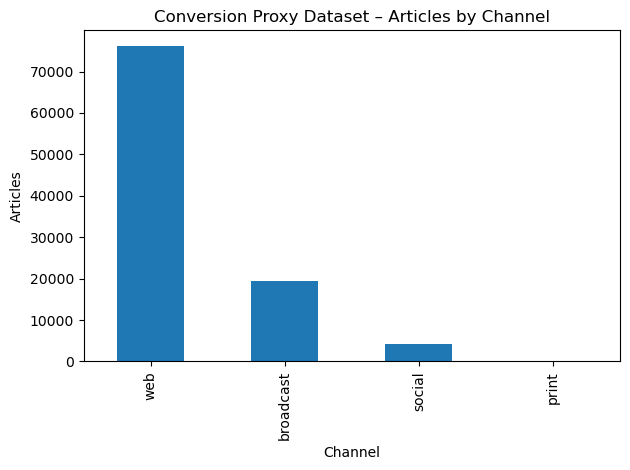

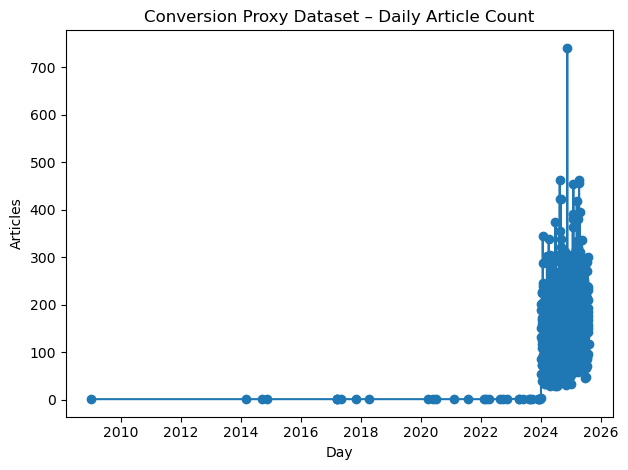

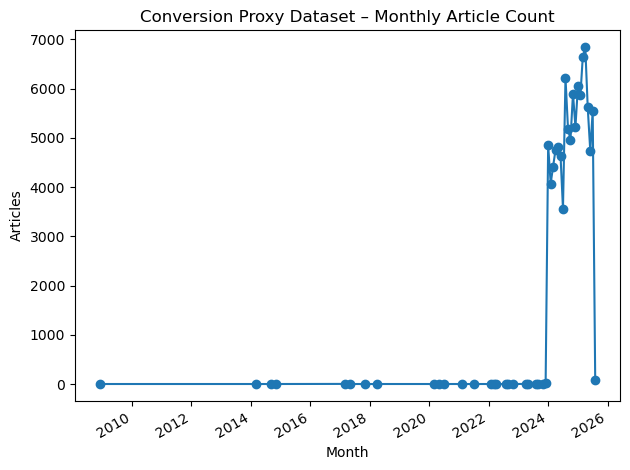

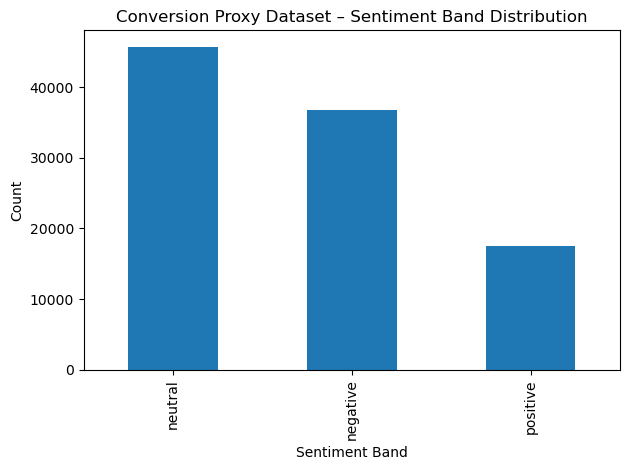

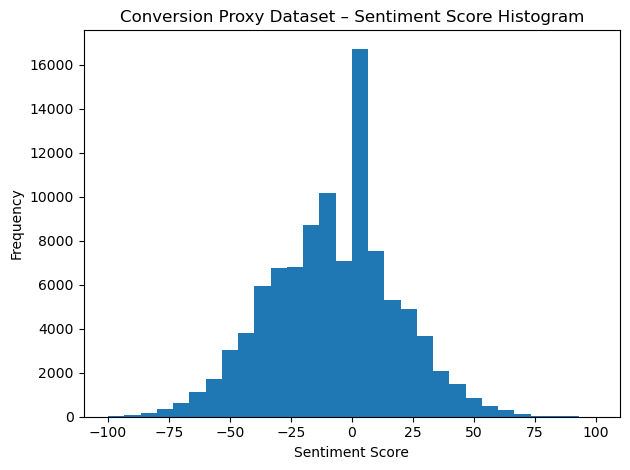

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def eda_visuals_matplotlib(df: pd.DataFrame, title_prefix: str = "EDA"):
    """
    Matplotlib EDA plots:
      1) Top 20 publications by article count
      2) Avg circulation by source type
      3) By channel: article count
      4) Daily article count
      5) Monthly article count
      6) Sentiment band distribution (count)
      7) Sentiment score histogram (if present)
    Notes:
      - Backend-agnostic datetime handling (Arrow-backed OK)
      - Groups in America/New_York calendar time
      - Does NOT set custom colors or styles (per your plotting rules)
    """

    # ---------------- Helpers ----------------
    def _ensure_cols(_df: pd.DataFrame) -> pd.DataFrame:
        _df = _df.copy()
        if "article_id" not in _df.columns:
            _df["article_id"] = 1
        if "circulation_size" not in _df.columns:
            _df["circulation_size"] = pd.NA
        if "publication_name" not in _df.columns:
            _df["publication_name"] = pd.NA
        if "channel_name" not in _df.columns:
            _df["channel_name"] = pd.NA
        if "sentiment_band" not in _df.columns:
            _df["sentiment_band"] = pd.NA
        return _df

    def _prep_time_keys(_df: pd.DataFrame):
        if "published_datetime" not in _df.columns:
            # Return empty Series if missing to simplify guards downstream
            empty = pd.Series([pd.NaT] * len(_df), index=_df.index)
            return empty, empty, empty
        # Parse as tz-aware UTC first, then convert to America/New_York
        pub = pd.to_datetime(_df["published_datetime"], errors="coerce", utc=True)
        pub_local = pub.dt.tz_convert("America/New_York")
        # Daily key: naive date
        day_key = pub_local.dt.tz_localize(None).dt.date
        # Monthly key: first day of month as naive timestamp (avoid .to_period)
        month_key = pd.to_datetime(pub_local.dt.strftime("%Y-%m-01")).dt.tz_localize(None)
        return pub_local, day_key, month_key

    def bar_from_series(s: pd.Series, title: str, xlabel: str, ylabel: str):
        if s.empty:
            return
        plt.figure()
        ax = s.plot(kind="bar")
        ax.set_title(f"{title_prefix} – {title}")
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        plt.tight_layout()
        plt.show()

    def line_from_series(s: pd.Series, title: str, xlabel: str, ylabel: str):
        if s.empty:
            return
        plt.figure()
        ax = s.plot(kind="line", marker="o")
        ax.set_title(f"{title_prefix} – {title}")
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        plt.tight_layout()
        plt.show()

    df = _ensure_cols(df)
    pub_local, day_key, month_key = _prep_time_keys(df)

    # ---------------- 1) Top 20 publications ----------------
    top_pubs = (
        df.groupby("publication_name", dropna=False)["article_id"]
          .count()
          .sort_values(ascending=False)
          .head(20)
    )
    bar_from_series(top_pubs, "Top Publications by Article Count", "Publication", "Articles")

    # ---------------- 2) Avg circulation by source type ----------------
    st_col = "source_type_name" if "source_type_name" in df.columns else ("source_type" if "source_type" in df.columns else None)
    if st_col is None:
        st_col = "source_type"
        if "source_type" not in df.columns:
            df["source_type"] = pd.NA

    avg_circ_by_st = (
        df.groupby(st_col, dropna=False)["circulation_size"]
          .mean()
          .sort_values(ascending=False)
    )
    bar_from_series(avg_circ_by_st, "Average Circulation by Source Type", "Source Type", "Avg Circulation")

    # ---------------- 3) By channel: article count ----------------
    by_channel = (
        df.groupby("channel_name", dropna=False)["article_id"]
          .count()
          .sort_values(ascending=False)
    )
    bar_from_series(by_channel, "Articles by Channel", "Channel", "Articles")

    # ---------------- 4) Daily article count ----------------
    if "published_datetime" in df.columns:
        daily_counts = (
            df.assign(_day=day_key)
              .groupby("_day")["article_id"]
              .count()
              .sort_index()
        )
        line_from_series(daily_counts, "Daily Article Count", "Day", "Articles")

    # ---------------- 5) Monthly article count ----------------
    if "published_datetime" in df.columns:
        monthly_counts = (
            df.assign(_month=month_key)
              .groupby("_month")["article_id"]
              .count()
              .sort_index()
        )
        line_from_series(monthly_counts, "Monthly Article Count", "Month", "Articles")

    # ---------------- 6) Sentiment band distribution (count) ----------------
    sb_counts = df["sentiment_band"].value_counts(dropna=False).sort_values(ascending=False)
    bar_from_series(sb_counts, "Sentiment Band Distribution", "Sentiment Band", "Count")

    # ---------------- 7) Sentiment score histogram ----------------
    if "sentiment_score" in df.columns and df["sentiment_score"].notna().any():
        plt.figure()
        df["sentiment_score"].dropna().astype(float).plot(kind="hist", bins=30)
        plt.title(f"{title_prefix} – Sentiment Score Histogram")
        plt.xlabel("Sentiment Score")
        plt.ylabel("Frequency")
        plt.tight_layout()
        plt.show()
        
eda_visuals_matplotlib(sampleDF, title_prefix="Conversion Proxy Dataset")